# Divergence‑Type Diffusion in (1+1)D with the Kurganov–Tadmor scheme

Solves the flux‑conservative system

$\partial_t n + \partial_x q = 0,\qquad
\partial_t(\Lambda q) + \partial_x\alpha + \frac{1}{\sigma T}q = 0$,

where $(n(\alpha)$ is the equilibrium charge density and $\Lambda,\sigma T$ are constant constitutive parameters.

L = 50.0, Nx = 1000, dx = 0.1000, t_end = 20.0
Simulation finished after 201 snapshots.
Saved to ./KT_DivType/snapshots.npz


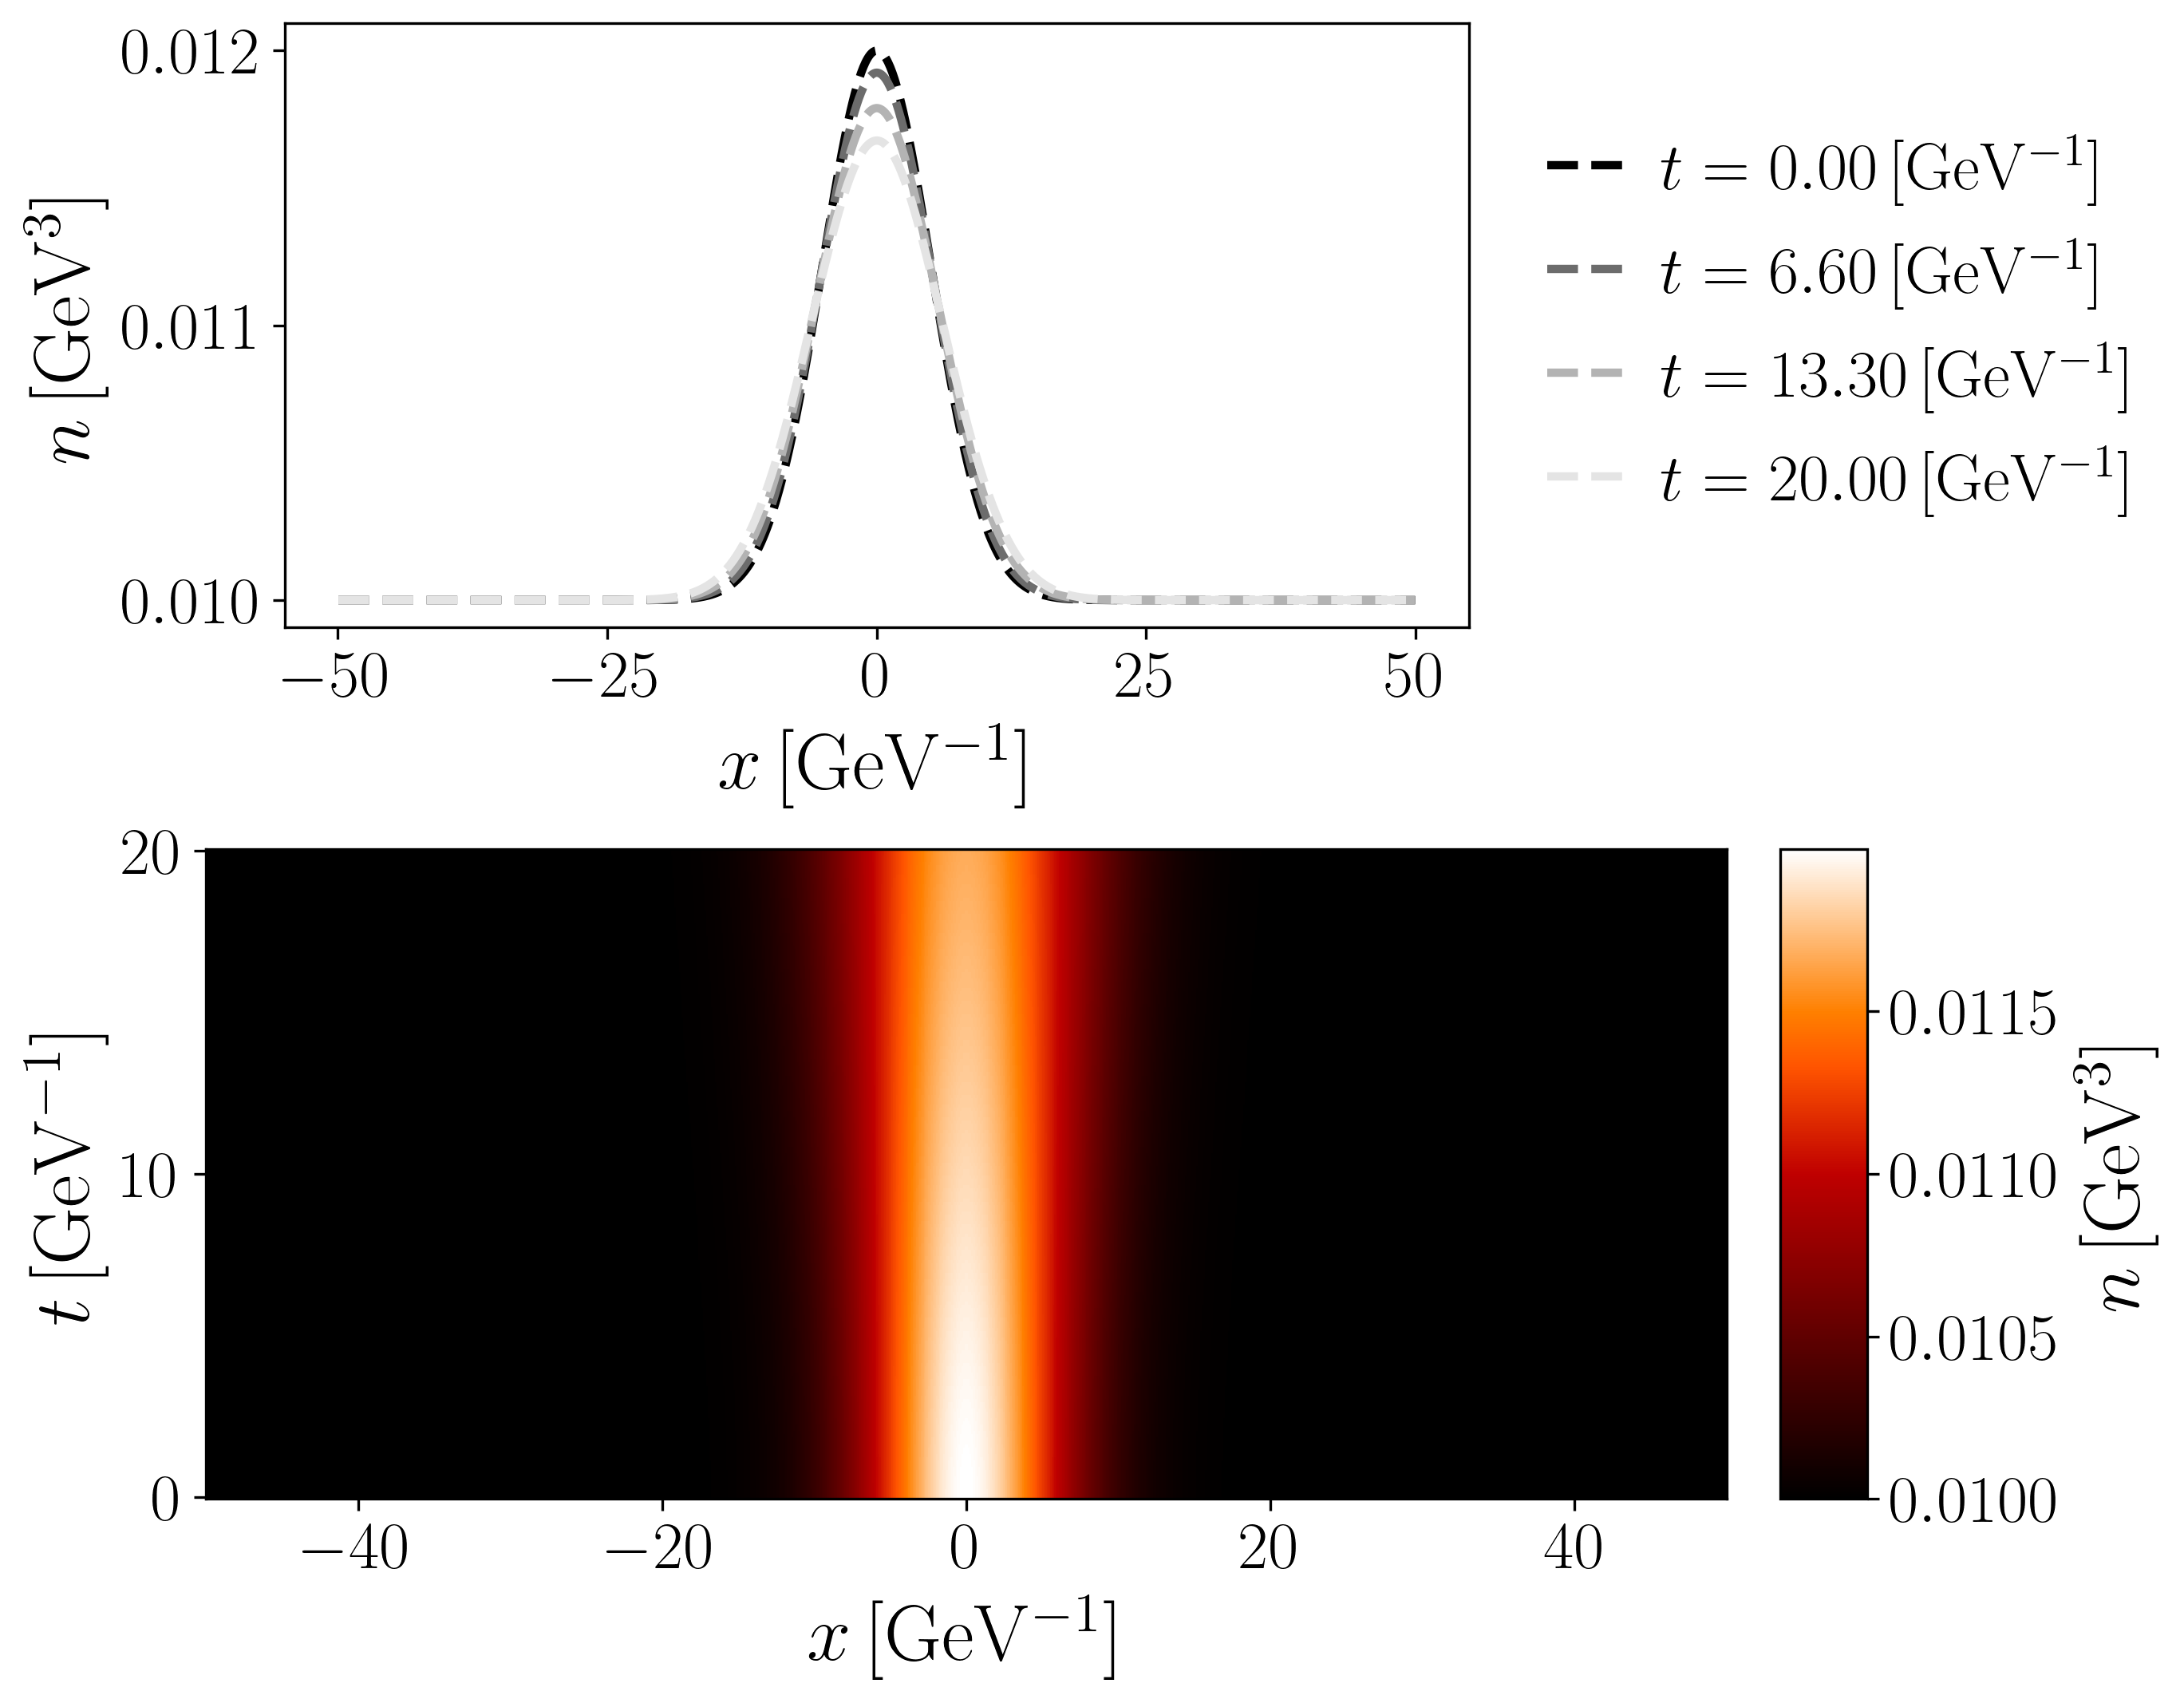

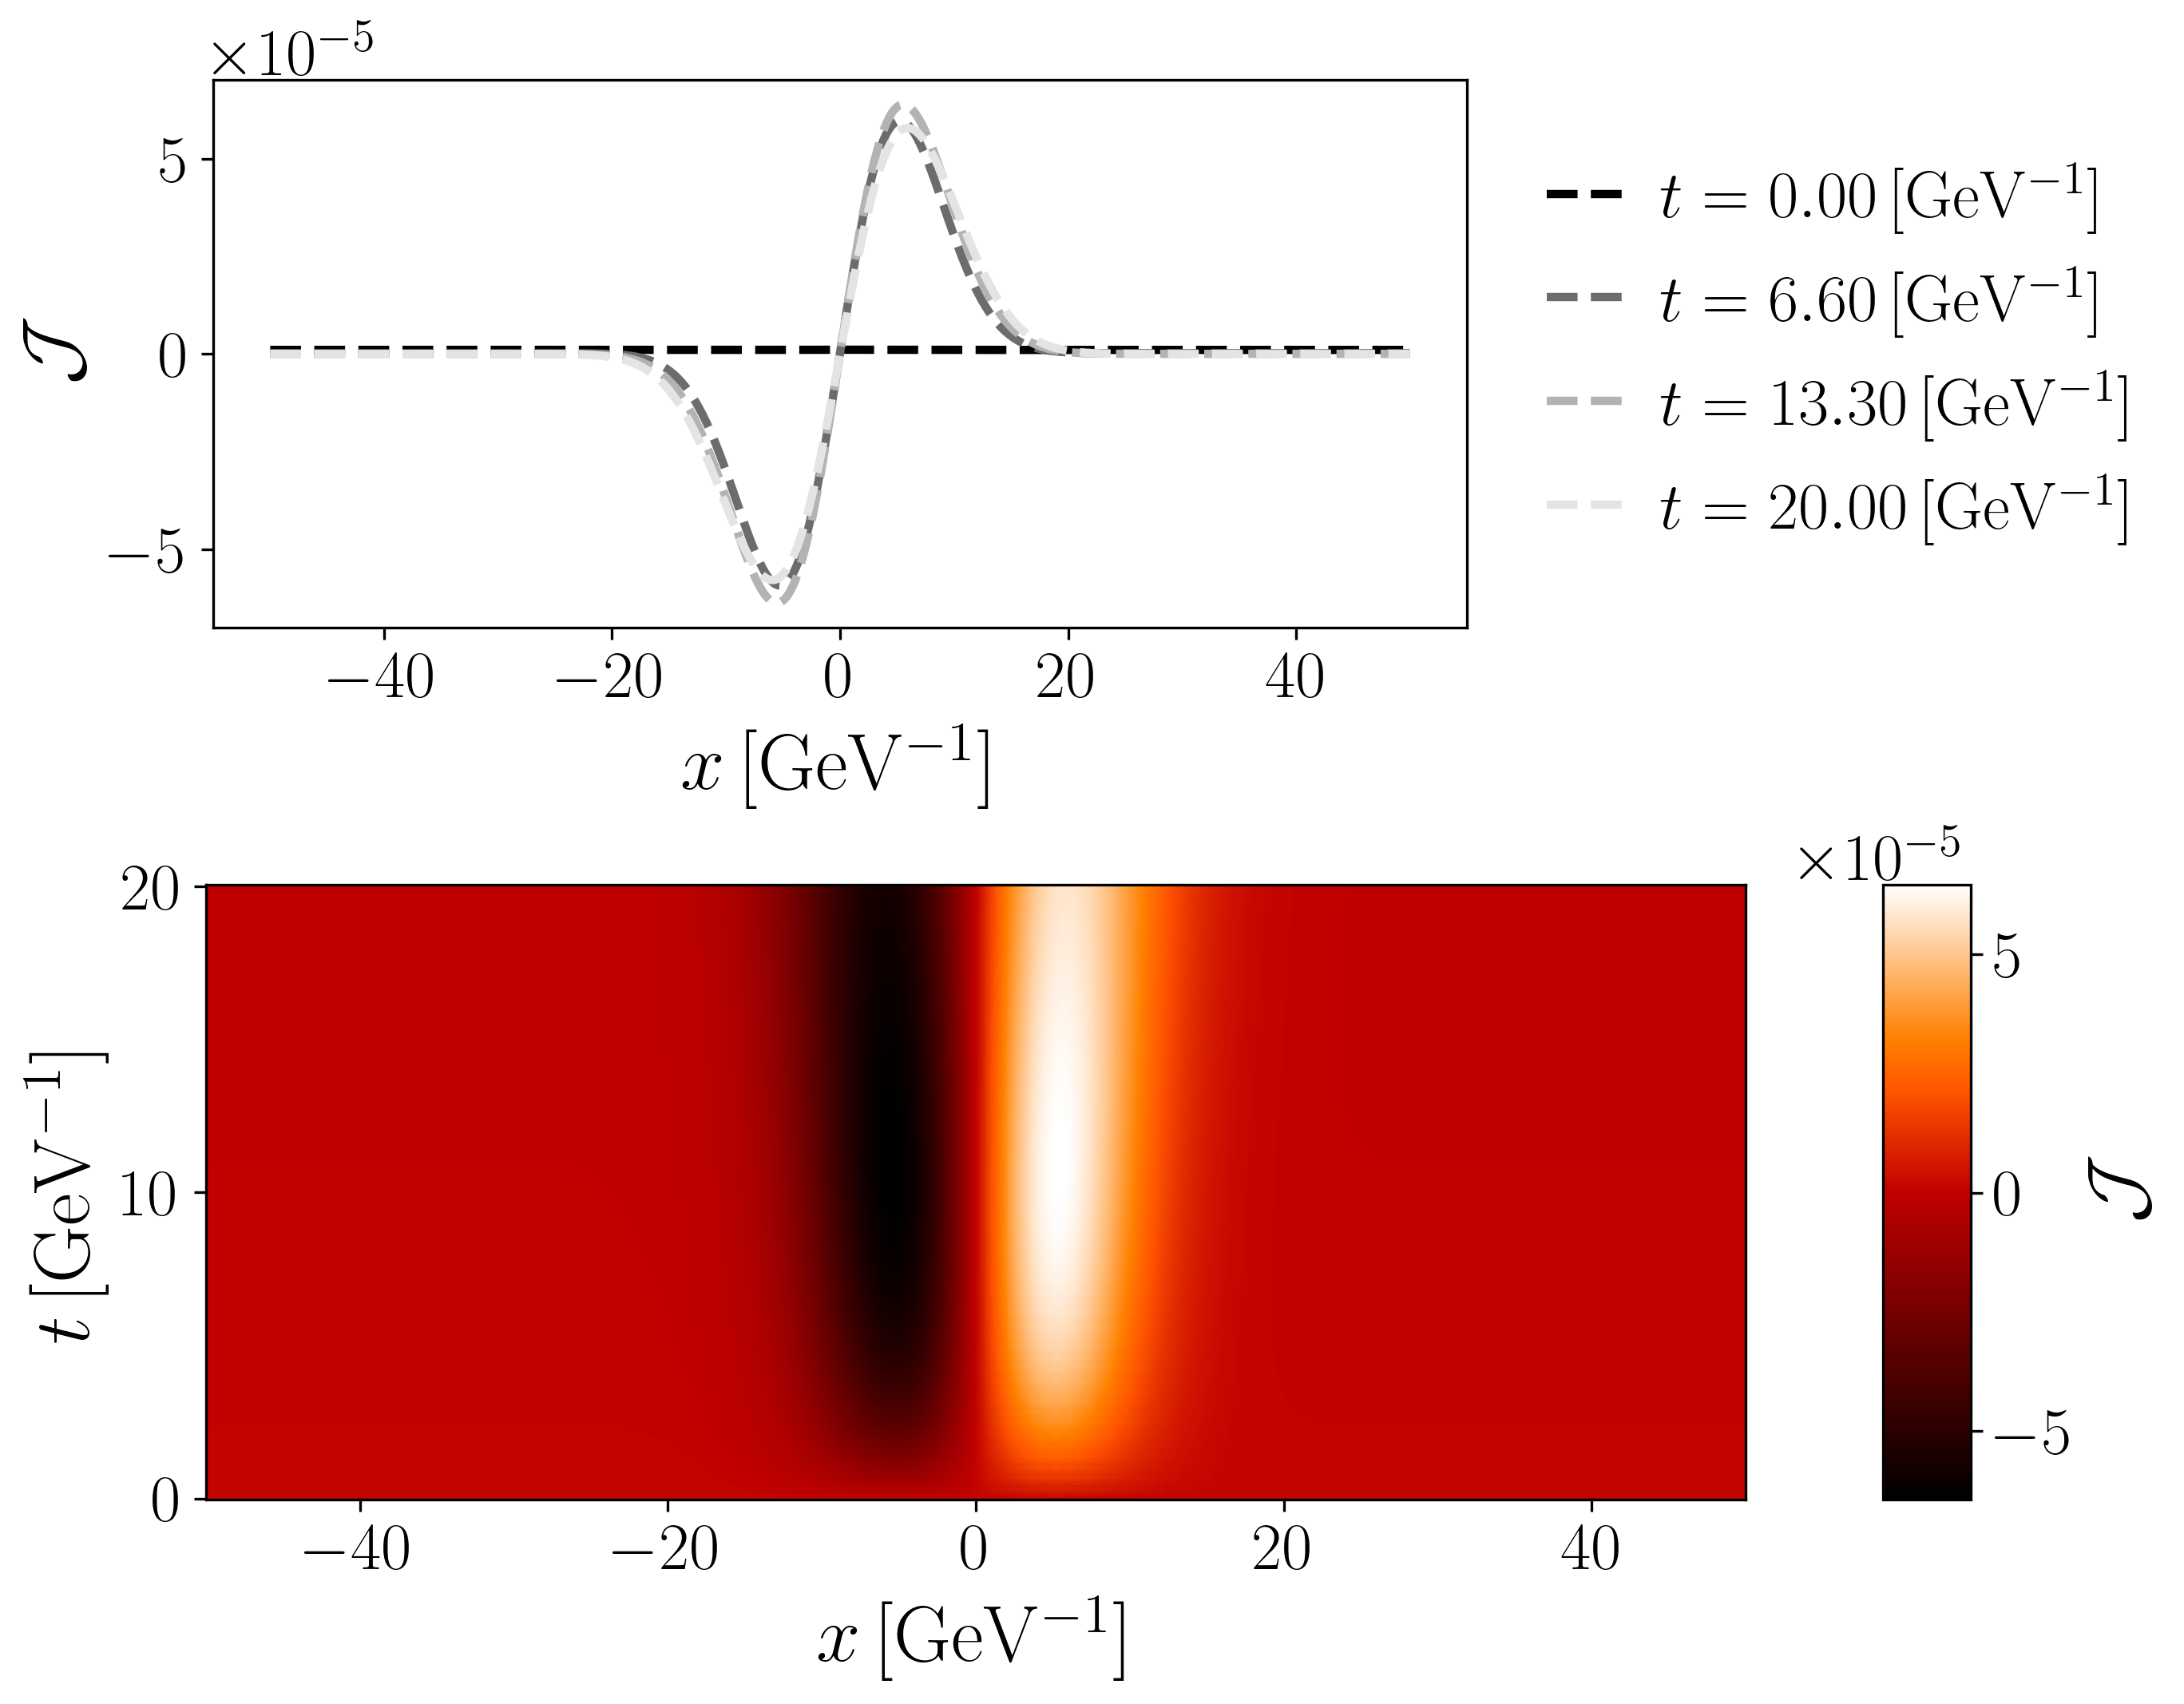

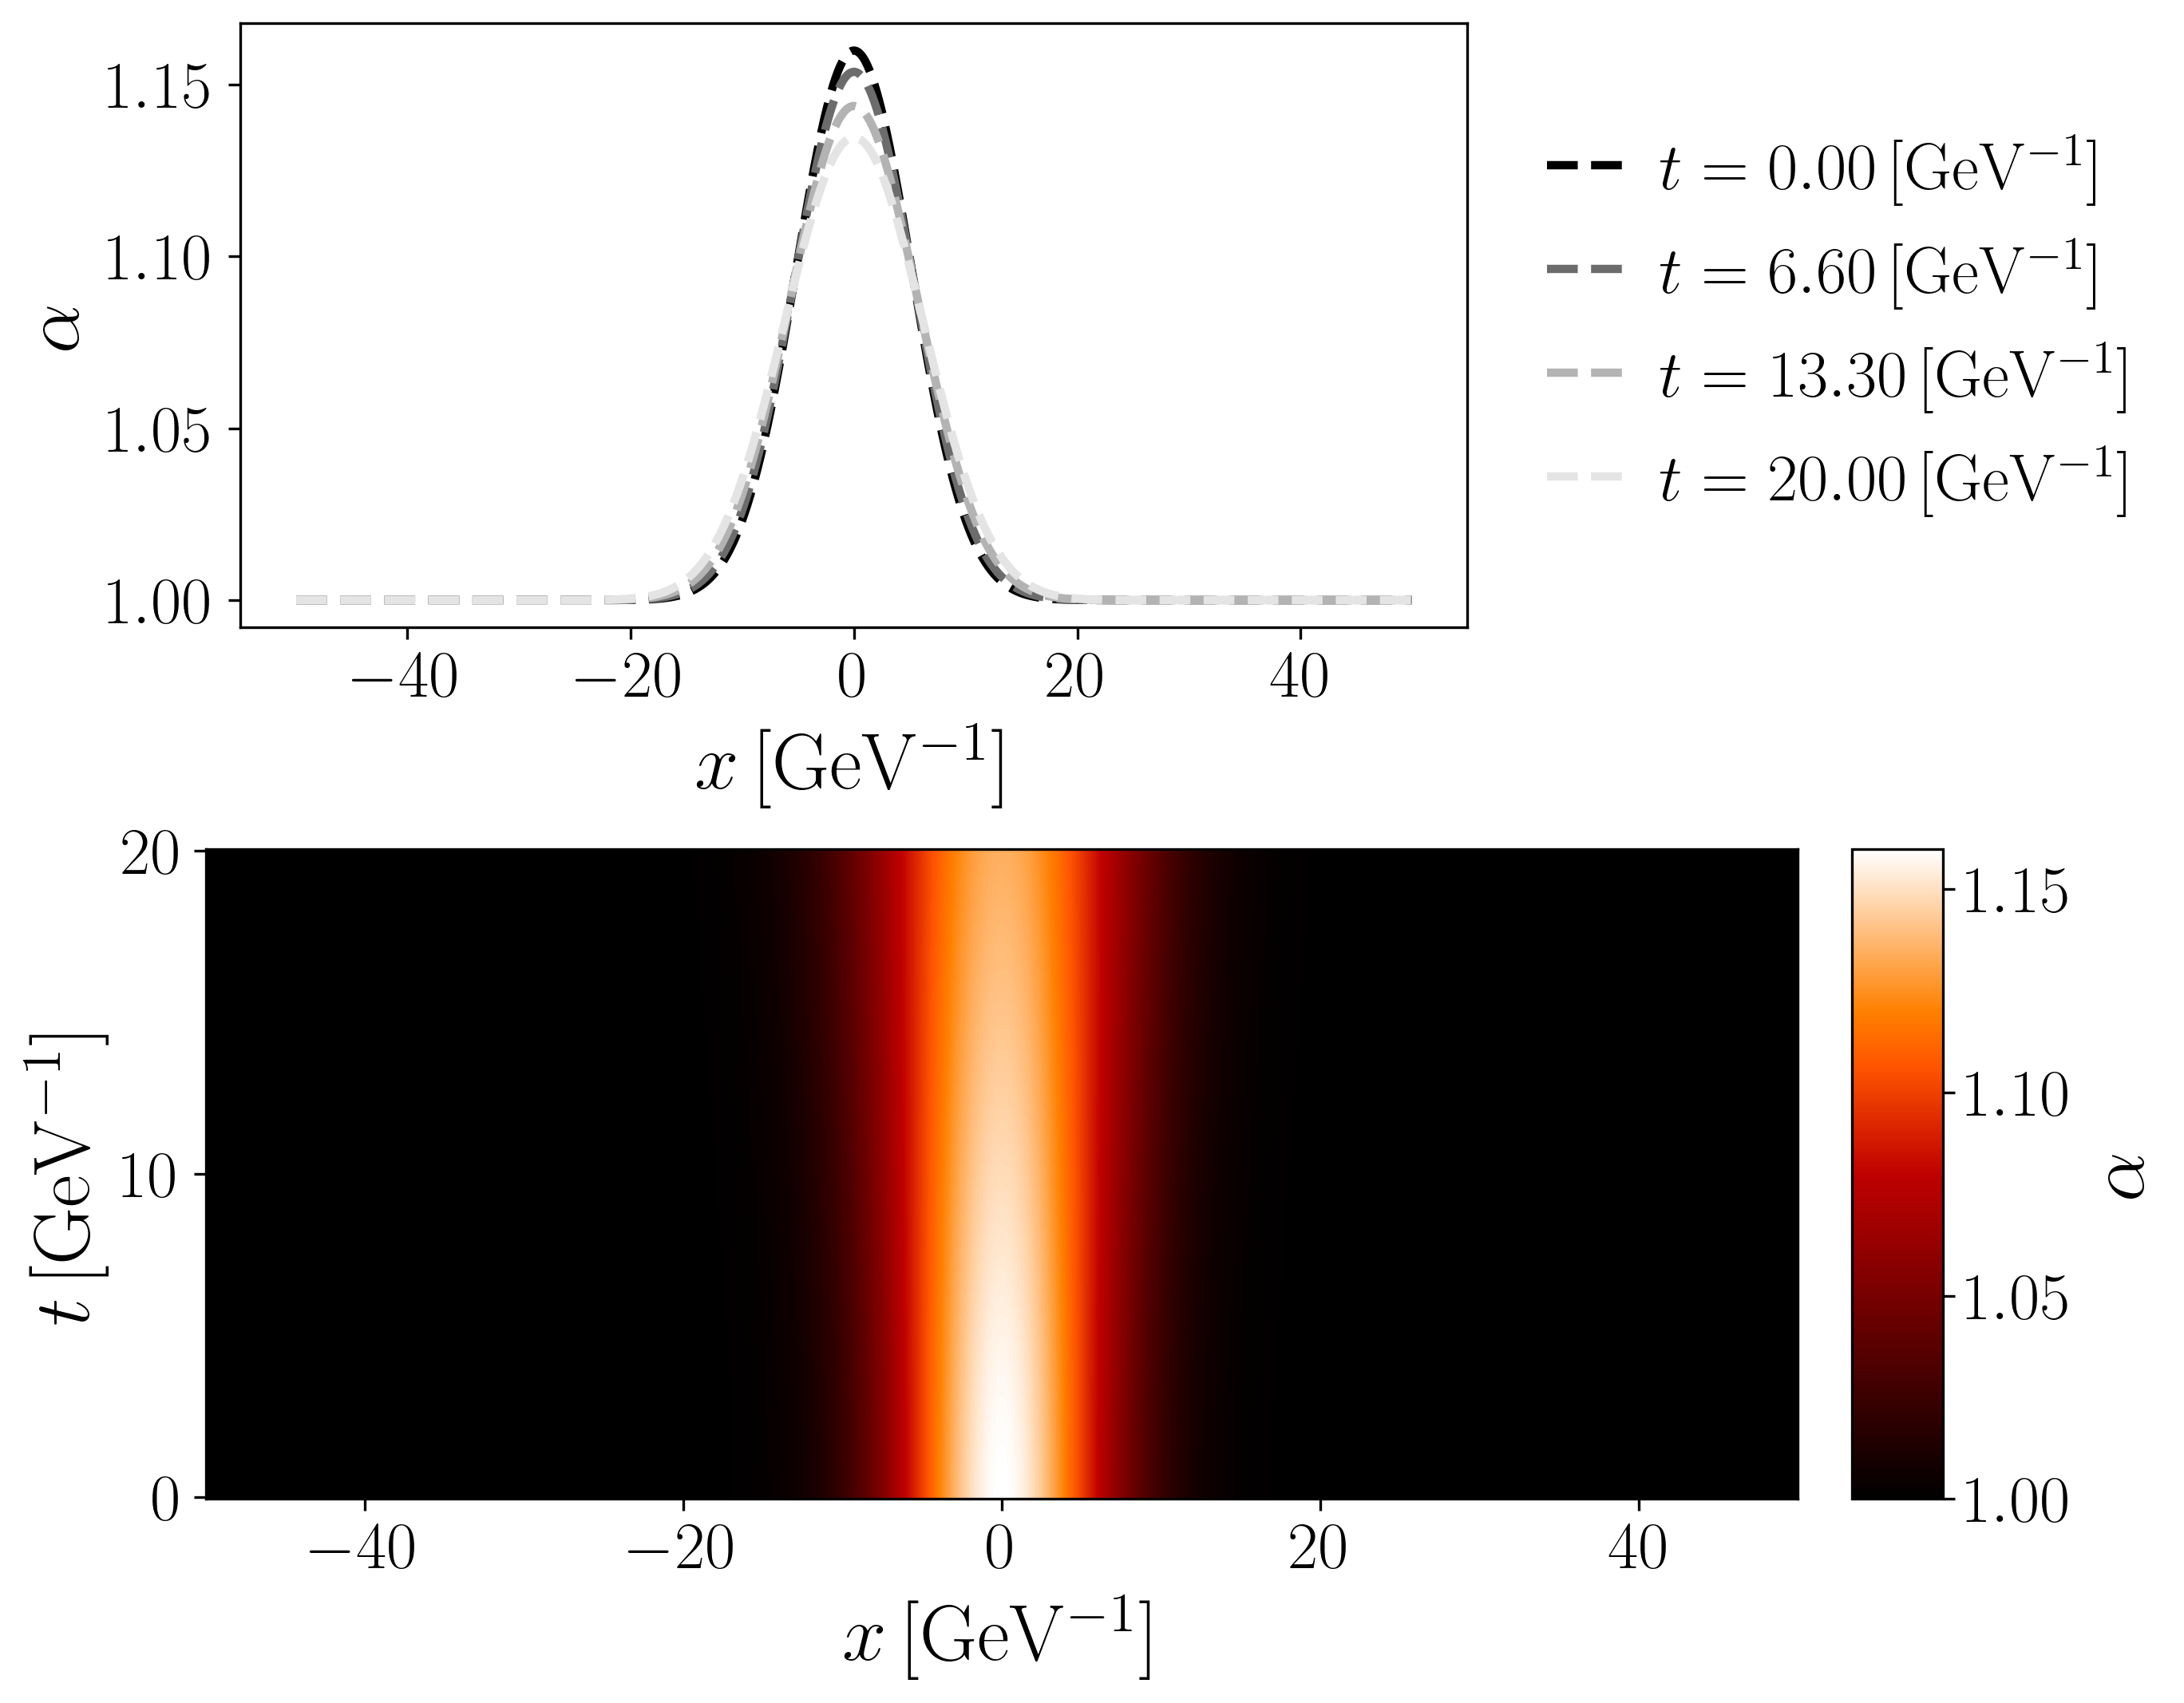

In [2]:
import numpy as np
from numba import jit
import matplotlib.pyplot as plt
import os

# ---------- physical parameters ----------
L         = 50.0
t_end     = 20.0
Nx        = 1000
dx        = 2.0 * L / Nx
xc        = np.linspace(-L + 0.5*dx, L - 0.5*dx, Nx)

T_const = 0.3
T_cube = T_const ** 3
lam = 1000.0           # λ = τ_J/(σT) = constant

# ---------- constitutive functions (new EOS) ----------
@jit(nopython=True, cache=False)
def n_func(alpha):
    """Charge density n(α) = (T³/3)α + (T³/27)α³."""
    return (T_cube / 3.0) * alpha + (T_cube / 27.0) * alpha**3

@jit(nopython=True, cache=False)
def sigma_func(alpha):
    """Conductivity σ(α) = (15T/(4π))(1/27 + α²/(243π²))."""
    return (15.0 * T_const / (4.0 * np.pi)) * (1.0/27.0 + alpha**2 / (243.0 * np.pi**2))

@jit(nopython=True, cache=False)
def sigmaT_func(alpha):
    """σT used in the source term."""
    return sigma_func(alpha) * T_const

@jit(nopython=True, cache=False)
def lambda_func(alpha):
    """Λ(α) = τ_J/(σT) = 12 / n(α)"""
    return 12.0 / n_func(alpha)      

@jit(nopython=True, cache=False)
def alpha_from_n_func(n):
    """Analytical inverse: solve T³/3 α + T³/27 α³ = n."""
    a = T_cube / 3.0
    b = T_cube / 27.0
    p = a / b
    q = -n / b
    delta = (q / 2.0)**2 + (p / 3.0)**3
    sqrt_delta = np.sqrt(delta)
    t1 = -q/2.0 + sqrt_delta
    t2 = -q/2.0 - sqrt_delta
    u = np.sign(t1) * np.power(np.abs(t1), 1.0/3.0)
    v = np.sign(t2) * np.power(np.abs(t2), 1.0/3.0)
    return u + v

@jit(nopython=True, cache=False)
def T_func(t, x):
    return T_const * np.ones_like(x)

# ---------- initial conditions ----------
@jit(nopython=True, cache=False)
def make_IC(xc):
    p, qq, r = 0.2, 7.0, 1.0
    n_init = (p * np.exp(-(qq * xc / L)**2) + r) * 1e-2 

    d, f, g = 0.05, 10.0, 1.05
    q_init = (d * np.exp(-(f * xc / L)**2) + g) * 1e-6 
    return n_init, q_init

# ---------- helper: periodic shift ----------
@jit(nopython=True, cache=False)
def roll1d(arr, shift):
    n = arr.size
    s = shift % n
    out = np.empty_like(arr)
    if s == 0:
        out[:] = arr
    else:
        out[:s] = arr[-s:]
        out[s:] = arr[:-s]
    return out

# ---------- numerical flux (Kurganov–Tadmor) ----------
@jit(nopython=True, cache=False)
def numerical_flux(n, lam_q, T_arr):
    """
    n     : charge density at cell centres  (Nx,)
    lam_q : λ q at cell centres             (Nx,)   here λ=1 so lam_q = q
    T_arr : temperature at cell centres     (Nx,)
    Returns face fluxes H (2, Nx).
    """
    # minmod slopes
    dn  = (roll1d(n, -1) - n) / dx
    dnp = (n - roll1d(n, 1)) / dx
    sn = np.zeros_like(n)
    for i in range(Nx):
        if dn[i] * dnp[i] > 0.0:
            sn[i] = min(abs(dn[i]), abs(dnp[i])) * np.sign(dn[i])

    dlam = (roll1d(lam_q, -1) - lam_q) / dx
    dlamp = (lam_q - roll1d(lam_q, 1)) / dx
    slam = np.zeros_like(lam_q)
    for i in range(Nx):
        if dlam[i] * dlamp[i] > 0.0:
            slam[i] = min(abs(dlam[i]), abs(dlamp[i])) * np.sign(dlam[i])

    # face values
    n_minus   = n + 0.5 * dx * sn
    lam_minus = lam_q + 0.5 * dx * slam
    n_plus    = roll1d(n, -1) - 0.5 * dx * roll1d(sn, -1)
    lam_plus  = roll1d(lam_q, -1) - 0.5 * dx * roll1d(slam, -1)

    # physical fluxes: F = (q, α)
    q_minus = lam_minus / lam
    q_plus  = lam_plus  / lam
    alpha_minus = alpha_from_n_func(n_minus)
    alpha_plus  = alpha_from_n_func(n_plus)

    # wave speeds: dα/dn from the new EOS
    dalpha_dn_minus = 1.0 / (n_func(alpha_minus + 1e-8) - n_func(alpha_minus)) * 1e-8
    dalpha_dn_plus  = 1.0 / (n_func(alpha_plus + 1e-8) - n_func(alpha_plus)) * 1e-8
    dalpha_dn_minus = np.maximum(np.abs(dalpha_dn_minus), 1e-12)
    dalpha_dn_plus  = np.maximum(np.abs(dalpha_dn_plus),  1e-12)
    a_max = np.maximum(np.sqrt(dalpha_dn_minus / lam),
                       np.sqrt(dalpha_dn_plus  / lam))

    # KT flux
    H = np.zeros((2, Nx))
    H[0] = 0.5 * (q_minus + q_plus) - 0.5 * a_max * (n_plus - n_minus)
    H[1] = 0.5 * (alpha_minus + alpha_plus) - 0.5 * a_max * (lam_plus - lam_minus)
    return H

# ---------- time stepping (RK2) ----------
@jit(nopython=True, cache=False)
def rhs(n, lam_q, T_arr):
    """d/dt (n, lam_q) = -div(F) + source."""
    H = numerical_flux(n, lam_q, T_arr)   # shape (2, Nx)
    dU = np.zeros((2, Nx))
    dU[0] = -(H[0] - roll1d(H[0], 1)) / dx
    # source term:
    alpha = alpha_from_n_func(n)
    Lam = lam  # constant Lambda
    dU[1] = -(H[1] - roll1d(H[1], 1)) / dx - lam_q / (Lam * sigmaT_func(alpha))
    return dU

@jit(nopython=True, cache=False)
def step_RK2(n, lam_q, T_arr, dt):
    k1 = rhs(n, lam_q, T_arr)
    n1   = n     + dt * k1[0]
    q1   = lam_q + dt * k1[1]
    k2 = rhs(n1, q1, T_arr)
    n_out   = n     + 0.5 * dt * (k1[0] + k2[0])
    lam_out = lam_q + 0.5 * dt * (k1[1] + k2[1])
    return n_out, lam_out

# ---------- main simulation ----------
print(f"L = {L}, Nx = {Nx}, dx = {dx:.4f}, t_end = {t_end}")

n, q0 = make_IC(xc)
lam_q = lam * q0

save_times = np.linspace(0, t_end, 201)
save_idx   = 0
n_store    = np.zeros((len(save_times), Nx))
q_store    = np.zeros((len(save_times), Nx))
alpha_store= np.zeros((len(save_times), Nx))

n_store[0]   = n
q_store[0]   = q0
alpha_store[0] = alpha_from_n_func(n)

t = 0.0
while t < t_end:
    T_arr = T_func(t, xc)
    # characteristic speed
    alpha_cur = alpha_from_n_func(n)
    dalpha_dn = 1.0 / (n_func(alpha_cur + 1e-8) - n_func(alpha_cur)) * 1e-8
    dalpha_dn = np.maximum(np.abs(dalpha_dn), 1e-12)
    a_max = np.sqrt(dalpha_dn / lam)
    dt_cfl = np.min(0.4 * dx / a_max)
    dt = min(dt_cfl, t_end - t)

    n, lam_q = step_RK2(n, lam_q, T_arr, dt)
    t += dt

    while save_idx+1 < len(save_times) and t >= save_times[save_idx+1]:
        save_idx += 1
        n_store[save_idx]   = n
        q_store[save_idx]   = lam_q / lam
        alpha_store[save_idx] = alpha_from_n_func(n)

print(f"Simulation finished after {save_idx+1} snapshots.")

# ---------- save results ----------
run_dir = "./KT_DivType"
os.makedirs(run_dir, exist_ok=True)
np.savez(os.path.join(run_dir, "snapshots.npz"),
         t=save_times, x=xc,
         n=n_store, q=q_store, alpha=alpha_store)
print(f"Saved to {run_dir}/snapshots.npz")

# %% [KT plots in PINN style]
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

# -------- use the same style as the PINN plotting module --------
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 18,
    'axes.titlesize': 24,
    'axes.labelsize': 24,
    'legend.fontsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'font.serif': ['Computer Modern Roman'],
    'text.latex.preamble': r'\usepackage{amsmath}',
    'figure.dpi': 300,
    'savefig.dpi': 300
})

def custom_colormap():
    cmap = plt.get_cmap("Greys_r", 256)
    vals = np.interp(
        np.linspace(0, 1, 256),
        [0.0, 1/3, 2/3, 1.0],
        [0.0, 0.35, 0.59, 0.81]
    )
    cmap = cmap(vals)
    return ListedColormap(cmap)

def plot_kt_field(field, x_eval, t_eval, ylabel, cmap_heat='gist_heat'):
    """Replica of Plotting_DivType.plot_field_panel for KT data."""
    Nt = len(t_eval)
    times = np.linspace(0, Nt-1, 4, dtype=int)
    cmap = plt.get_cmap(custom_colormap())

    fig = plt.figure(figsize=(9, 7), constrained_layout=True)
    outer = gridspec.GridSpec(2, 1, figure=fig,
                              height_ratios=[0.48, 0.52], hspace=0.18)

    gs_top = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer[0],
        width_ratios=[1.15, 0.32], wspace=0.05)
    ax_snap = fig.add_subplot(gs_top[0, 0])
    ax_leg  = fig.add_subplot(gs_top[0, 1])

    gs_bot = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer[1],
        width_ratios=[1.05, 0.06], wspace=0.05)
    ax_heat = fig.add_subplot(gs_bot[0, 0])
    cax     = fig.add_subplot(gs_bot[0, 1])

    for i, ti in enumerate(times):
        ax_snap.plot(
            x_eval, field[ti],
            color=cmap(i/(len(times)-1)),
            ls='--', lw=2.5,
            label=fr'$t={t_eval[ti]:.2f}\,[\mathrm{{GeV^{{-1}}}}]$'
        )

    ax_snap.set_xlabel(r'$x\,{\rm [GeV^{-1}]}$')
    ax_snap.set_ylabel(ylabel)

    ax_leg.axis('off')
    h, l = ax_snap.get_legend_handles_labels()
    ax_leg.legend(h, l, loc='center', frameon=False,
                  handlelength=1.2, handletextpad=0.5)

    pcm = ax_heat.pcolormesh(x_eval, t_eval, field,
                             shading='auto', cmap=cmap_heat)
    ax_heat.set_xlabel(r'$x\,{\rm [GeV^{-1}]}$')
    ax_heat.set_ylabel(r'$t\,{\rm [GeV^{-1}]}$')

    cb = fig.colorbar(pcm, cax=cax)
    cb.set_label(ylabel)
    plt.show()

# -------- generate the three panels --------
# Make sure t_eval and x_eval are the same arrays used for PINN plots.
# Here we use save_times (1D) and xc (1D) from the KT simulation.
# The field arrays have shape (Nt, Nx) with Nt = len(save_times).
plot_kt_field(n_store, xc, save_times, ylabel=r'$n\,{\rm [GeV^3]}$')
plot_kt_field(q_store, xc, save_times, ylabel=r'$\mathcal{J}$')
plot_kt_field(alpha_store, xc, save_times, ylabel=r'$\alpha$')

### ***Diagnostics:*** charge, causality, residuals

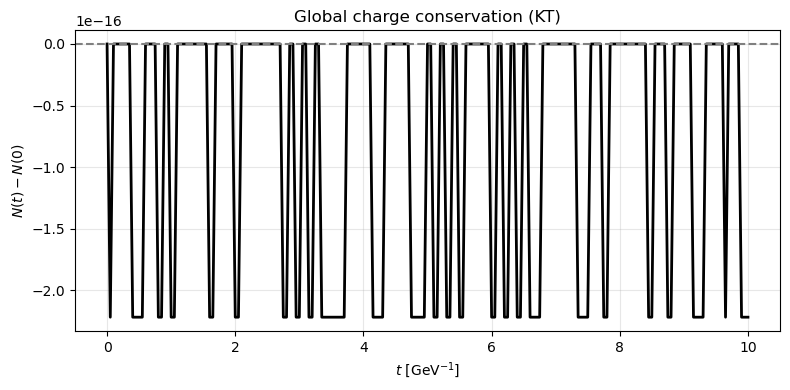

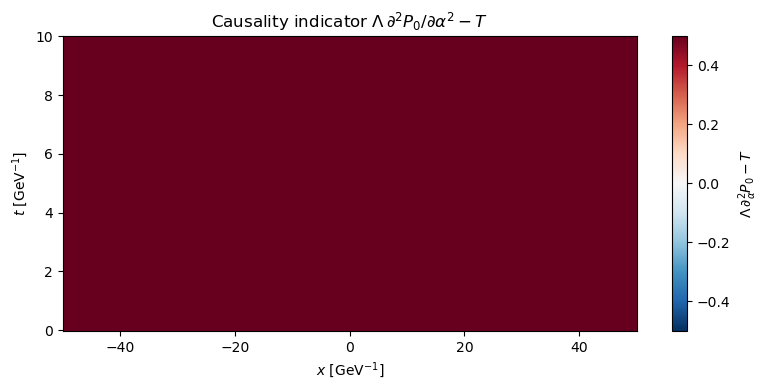

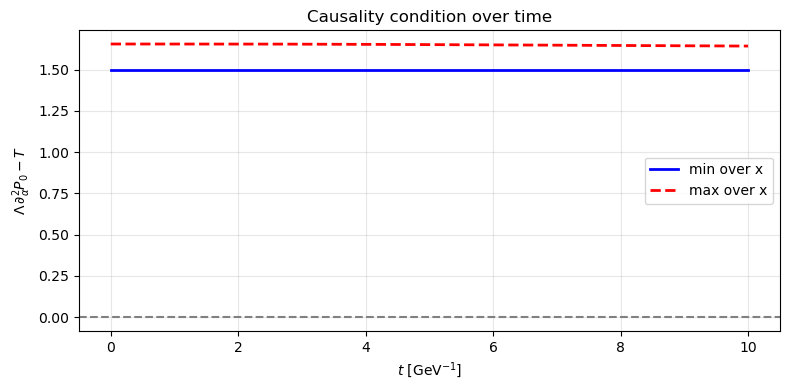

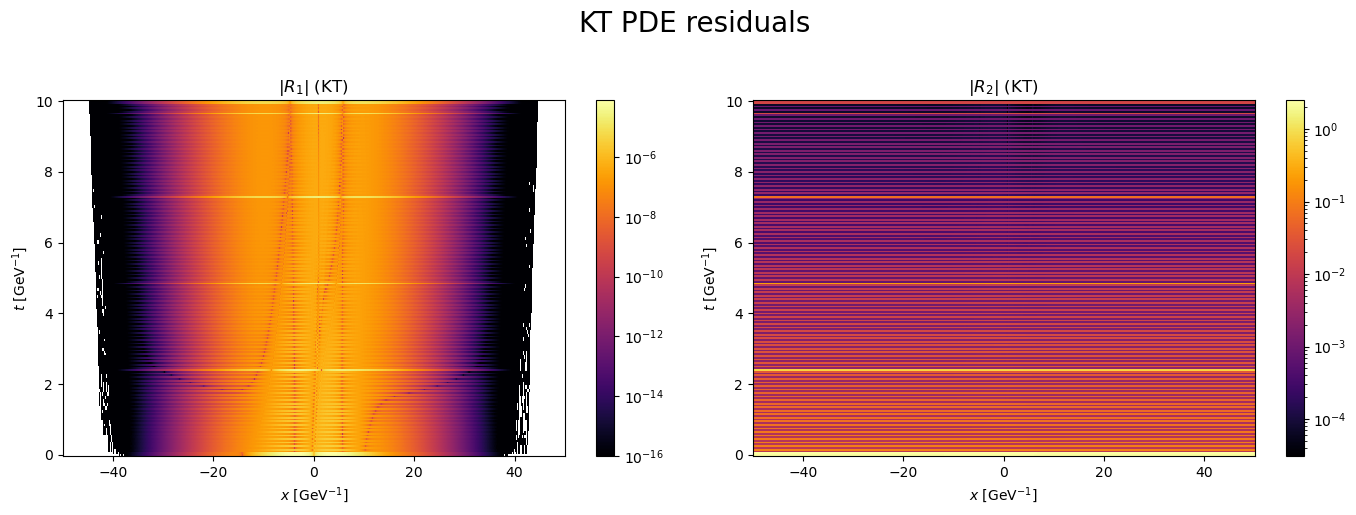

In [2]:
# %% [Diagnostics – load KT data first]
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ---------- Load the previously saved KT snapshot ----------
data = np.load("./KT_DivType/snapshots.npz")
save_times = data["t"]          # shape (201,)
xc         = data["x"]          # shape (1000,)
n_store    = data["n"]          # shape (201, 1000)
q_store    = data["q"]
alpha_store = data["alpha"]

# Re‑create the transport functions needed for residuals
T_const = 0.3
T_cube  = T_const ** 3
lam     = 500.0

def sigma_func(alpha):
    return (15.0 * T_const / (4.0 * np.pi)) * (1.0/27.0 + alpha**2 / (243.0 * np.pi**2))

def sigmaT_func(alpha):
    return sigma_func(alpha) * T_const

# ---------- 1. Global charge conservation ----------
dx_kt = xc[1] - xc[0]
N_t = n_store.sum(axis=1) * dx_kt
N0 = N_t[0]
charge_error = N_t - N0

fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(save_times, charge_error, 'k-', lw=2)
ax1.axhline(0, color='gray', ls='--')
ax1.set_xlabel(r'$t$ [GeV${}^{-1}$]')
ax1.set_ylabel(r'$N(t) - N(0)$')
ax1.set_title('Global charge conservation (KT)')
ax1.grid(True, alpha=0.3)
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.tight_layout()
plt.show()

# ---------- 2. Causality condition ----------
T_val = T_const
d2P0 = (T_const**4 / 3.0) + (T_const**4 / 9.0) * alpha_store**2
causality_measure = lam * d2P0 - T_val

fig2, ax2 = plt.subplots(figsize=(8, 4))
im2 = ax2.pcolormesh(xc, save_times, causality_measure, shading='auto',
                     cmap='RdBu_r', vmin=-0.5, vmax=0.5)
ax2.set_xlabel(r'$x$ [GeV${}^{-1}$]')
ax2.set_ylabel(r'$t$ [GeV${}^{-1}$]')
ax2.set_title(r'Causality indicator $\Lambda\, \partial^2 P_0/\partial\alpha^2 - T$')
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label(r'$\Lambda\,\partial_{\alpha}^2 P_0 - T$')
plt.tight_layout()
plt.show()

# Time evolution
min_caus = causality_measure.min(axis=1)
max_caus = causality_measure.max(axis=1)
fig2b, ax2b = plt.subplots(figsize=(8, 4))
ax2b.plot(save_times, min_caus, 'b-', lw=2, label='min over x')
ax2b.plot(save_times, max_caus, 'r--', lw=2, label='max over x')
ax2b.axhline(0, color='gray', ls='--')
ax2b.set_xlabel(r'$t$ [GeV${}^{-1}$]')
ax2b.set_ylabel(r'$\Lambda\,\partial_{\alpha}^2 P_0 - T$')
ax2b.legend()
ax2b.grid(True, alpha=0.3)
ax2b.set_title('Causality condition over time')
plt.tight_layout()
plt.show()

# ---------- 3. PDE residuals (R1, R2) ----------
dt_kt = save_times[1] - save_times[0]
dx_kt = xc[1] - xc[0]

nt  = np.gradient(n_store, dt_kt, axis=0)
qx  = np.gradient(q_store, dx_kt, axis=1)
R1 = nt + qx

lam_q = lam * q_store
lam_qt = np.gradient(lam_q, dt_kt, axis=0)
alpha_x = np.gradient(alpha_store, dx_kt, axis=1)
sigT = sigmaT_func(alpha_store)
R2 = lam_qt + alpha_x + q_store / sigT

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title in zip(axes3,
                           [np.abs(R1), np.abs(R2)],
                           [r'$|R_1|$ (KT)', r'$|R_2|$ (KT)']):
    im = ax.pcolormesh(xc, save_times, data, shading='auto',
                       norm=LogNorm(vmin=max(1e-16, data[data>0].min()),
                                    vmax=data.max()),
                       cmap='inferno')
    ax.set_xlabel(r'$x$ [GeV${}^{-1}$]')
    ax.set_ylabel(r'$t$ [GeV${}^{-1}$]')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.suptitle('KT PDE residuals', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

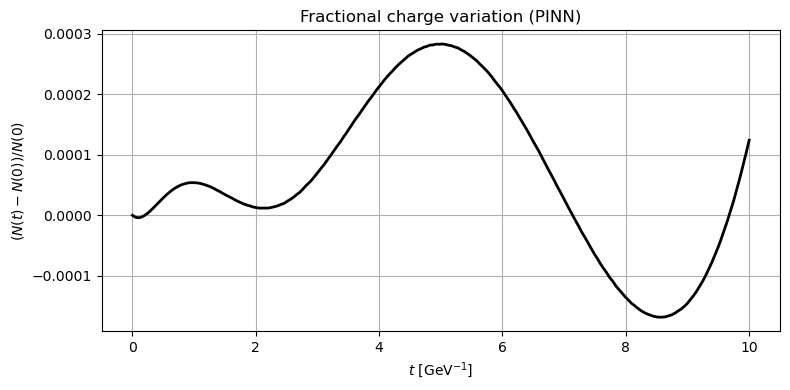

Charge conserved up to a fraction of 2.8e-04


In [7]:
# %% Mass (charge) conservation check – load from saved file
import numpy as np
import matplotlib.pyplot as plt

# ---- Load the saved PINN data (adjust the filename to your latest run) ----
pinn_data = np.load("./pinn_runs/divtype_pinn_20260611_181021.npz")  # <-- use your run_id
t_eval = pinn_data["t_eval"]
x_eval = pinn_data["x_eval"]
n_grid = pinn_data["n"]          # charge density already stored

dx_eval = x_eval[1] - x_eval[0]
N_t = n_grid.sum(axis=1) * dx_eval
N0 = N_t[0]

fig, ax = plt.subplots(figsize=(8, 4))
frac_var = (N_t - N0) / N0
ax.plot(t_eval, frac_var, 'k-', lw=2)
ax.set_xlabel(r'$t$ [GeV${}^{-1}$]')
ax.set_ylabel(r'$(N(t)-N(0)) / N(0)$')
ax.set_title('Fractional charge variation (PINN)')
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"Charge conserved up to a fraction of {np.max(np.abs(frac_var)):.1e}")

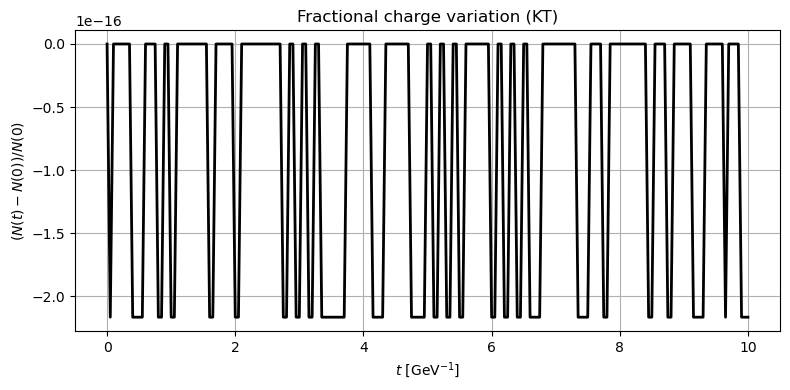

KT charge conserved up to a fraction of 2.2e-16


In [8]:
# %% Fractional charge conservation for KT
import numpy as np
import matplotlib.pyplot as plt

# Load KT snapshot
kt_data = np.load("./KT_DivType/snapshots.npz")
t_kt = kt_data["t"]
x_kt = kt_data["x"]
n_kt = kt_data["n"]

dx_kt = x_kt[1] - x_kt[0]
N_t = n_kt.sum(axis=1) * dx_kt
N0 = N_t[0]

fig, ax = plt.subplots(figsize=(8, 4))
frac_var = (N_t - N0) / N0
ax.plot(t_kt, frac_var, 'k-', lw=2)
ax.set_xlabel(r'$t$ [GeV${}^{-1}$]')
ax.set_ylabel(r'$(N(t)-N(0)) / N(0)$')
ax.set_title('Fractional charge variation (KT)')
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"KT charge conserved up to a fraction of {np.max(np.abs(frac_var)):.1e}")

### Convergence Test

  Running Nx=250 ...  done in 2.8s
  Running Nx=500 ...  done in 2.1s
  Running Nx=1000 ...  done in 2.3s

Wall-clock times:
  Nx=  250: 2.82 s
  Nx=  500: 2.11 s
  Nx= 1000: 2.32 s
  Total:  7.24 s

Convergence metric Q_n at t = 5.0 GeV⁻¹:
  Q_n(t=5.0) = 1.904  (≈2nd order ✓)
  Q_q(t=5.0) = 2.134  (≈2nd order ✓)
  Q_alpha(t=5.0) = 1.905  (≈2nd order ✓)


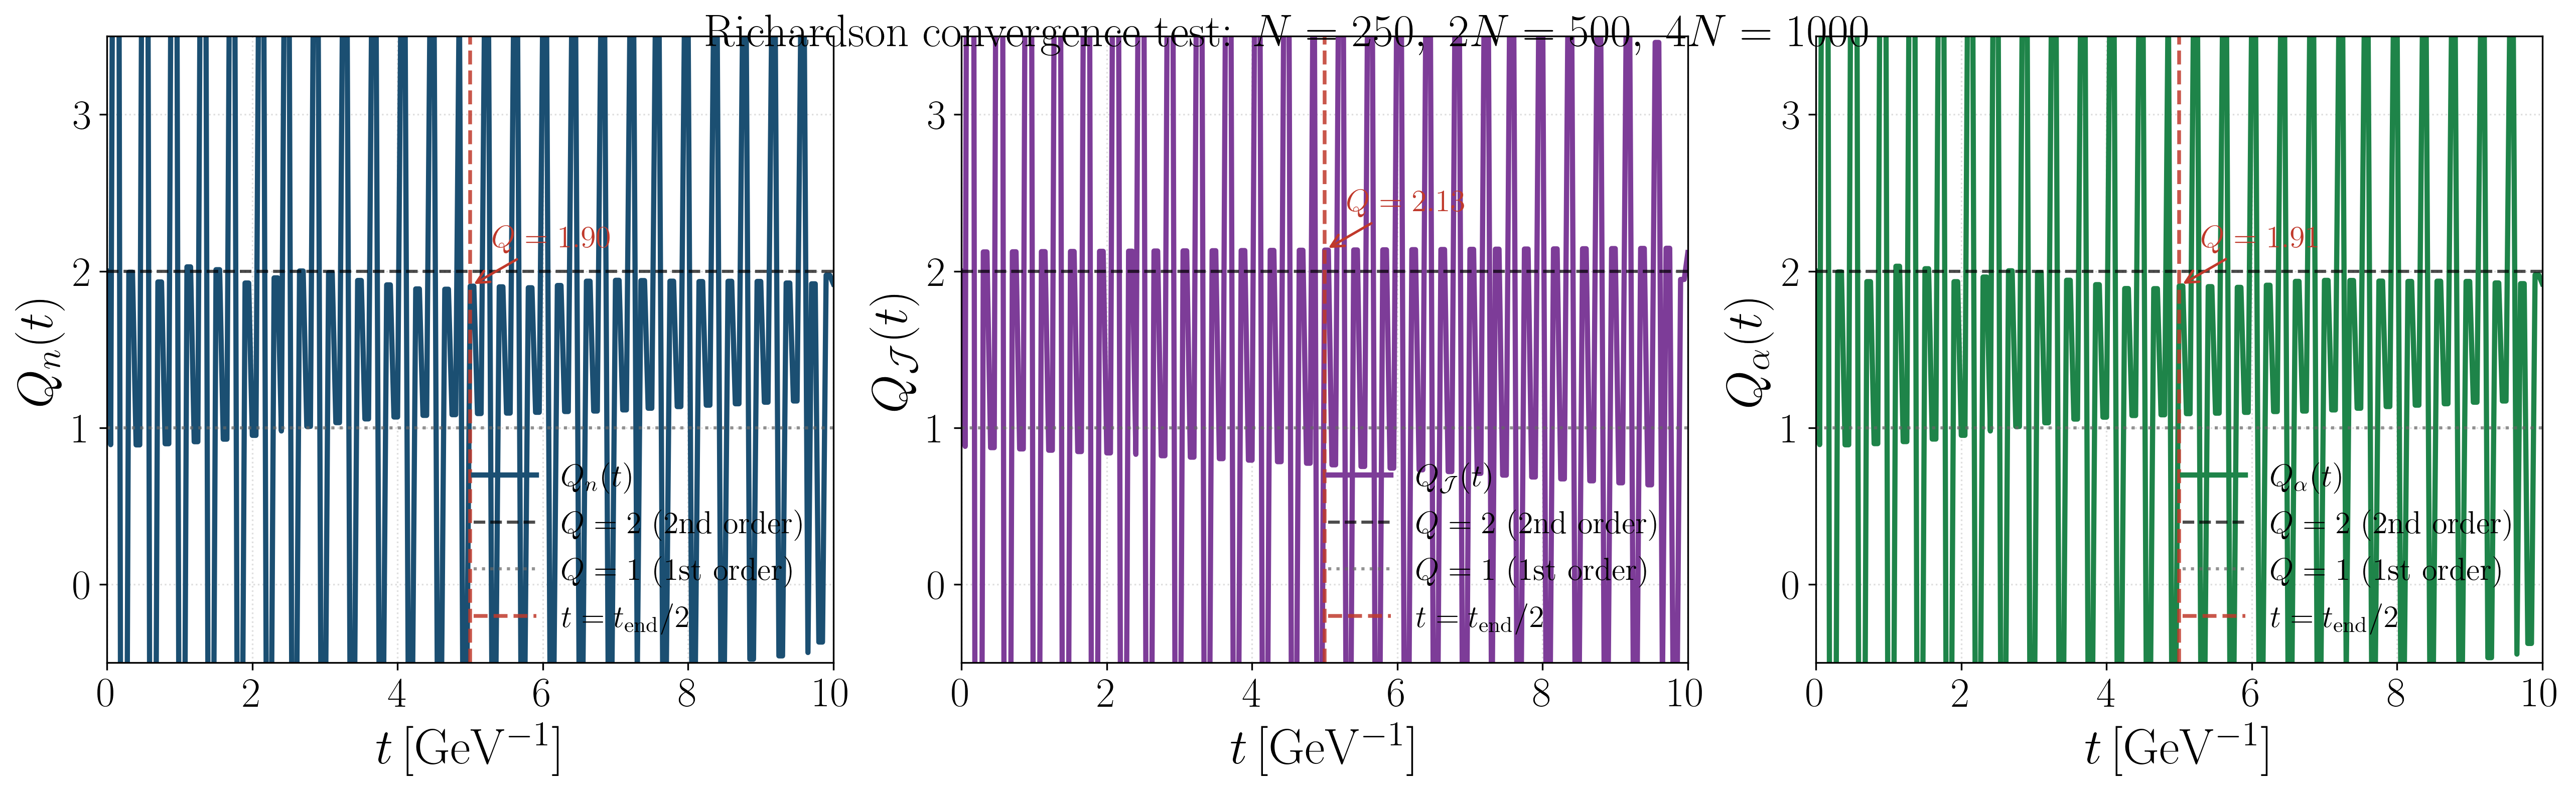

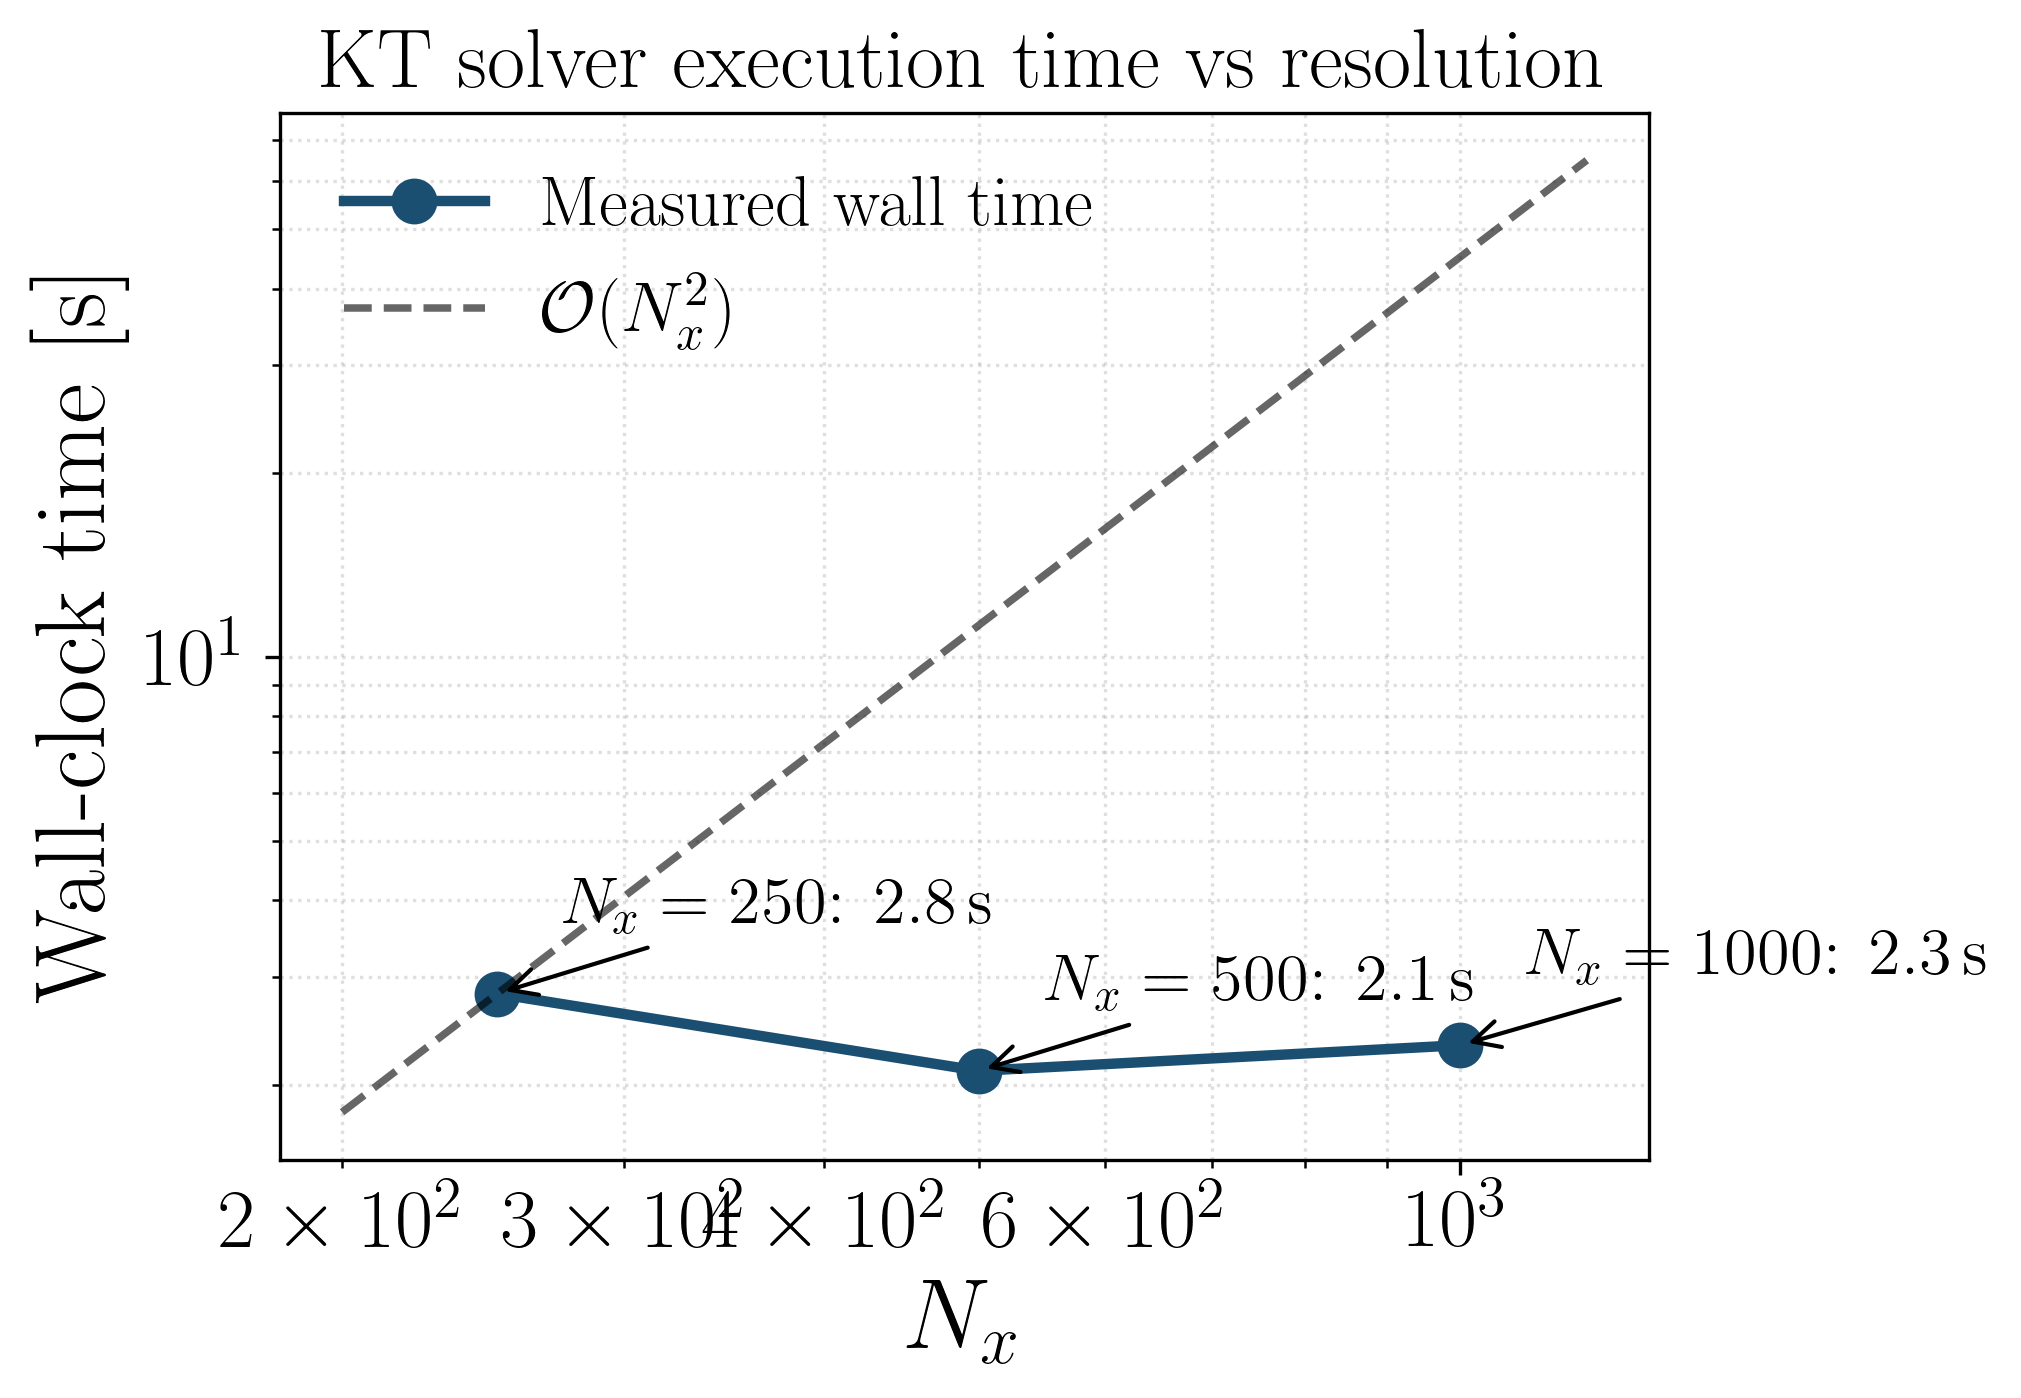

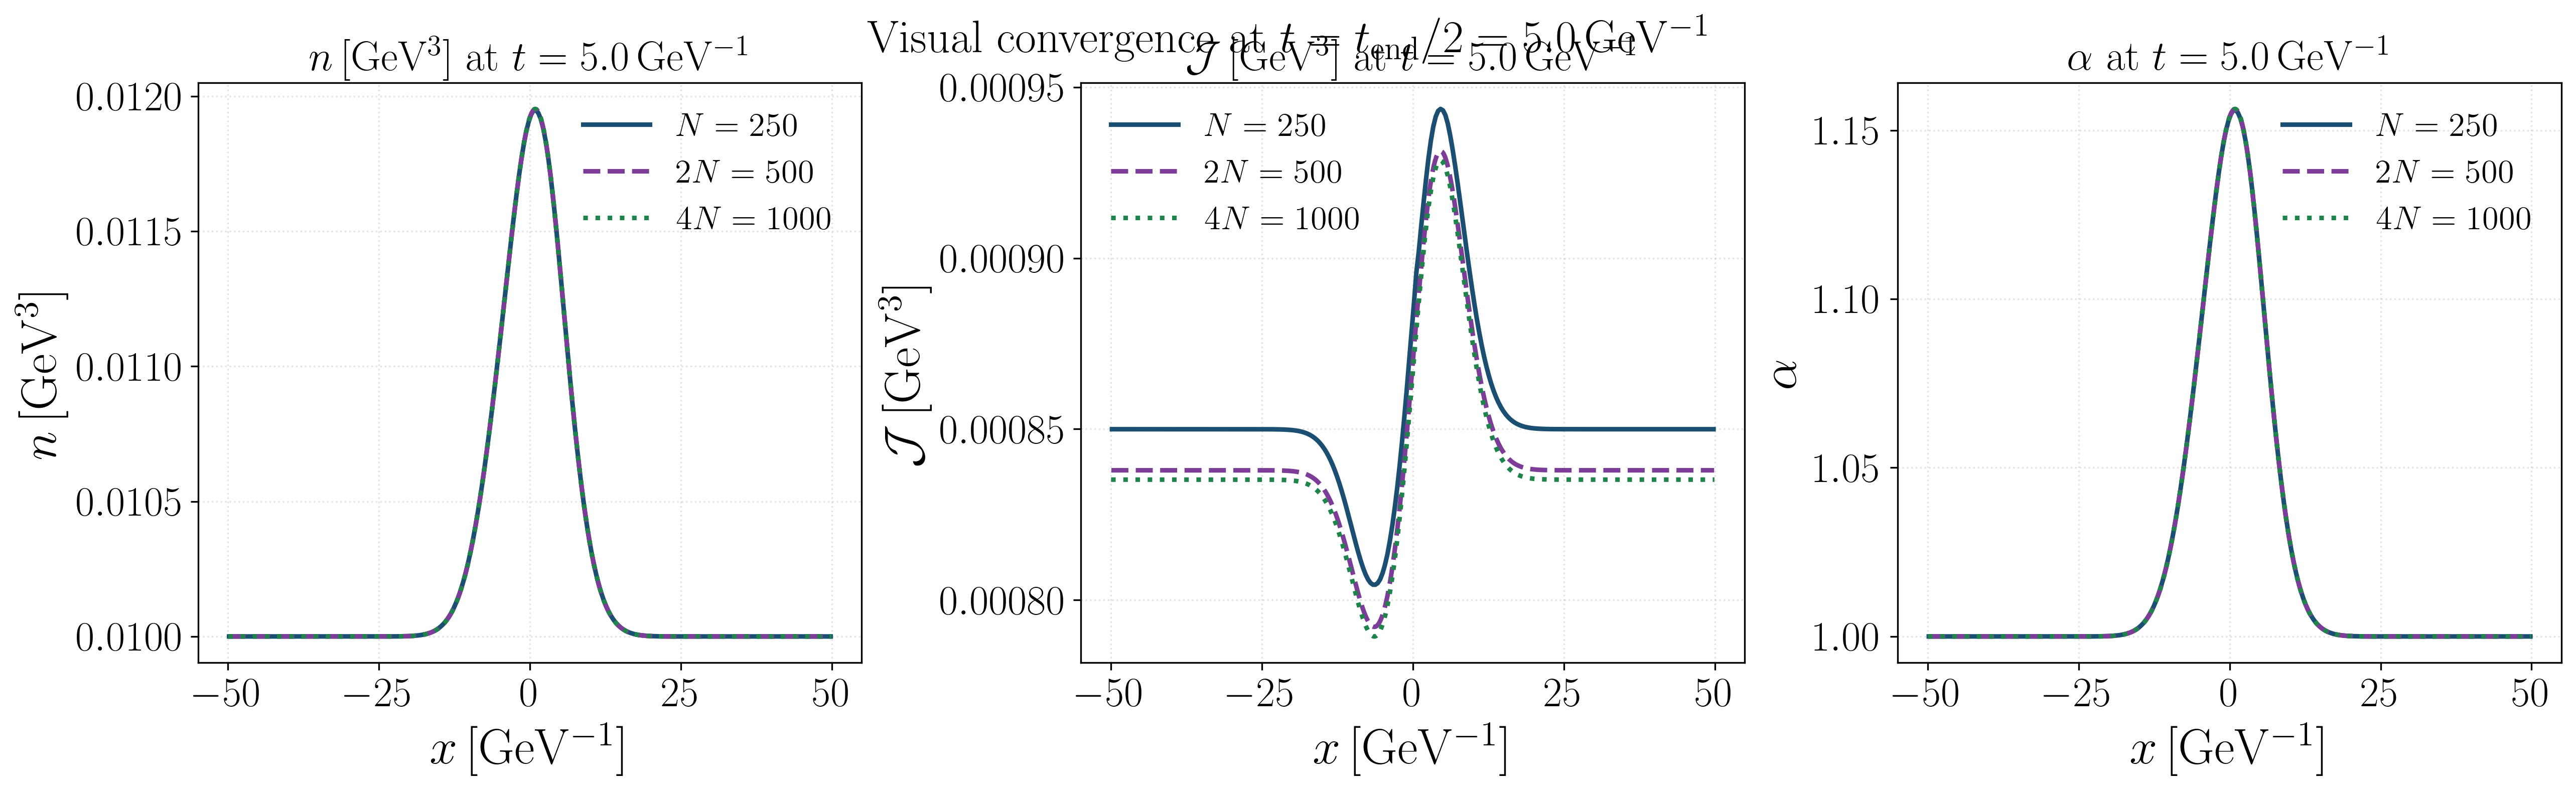


CONVERGENCE SUMMARY
   t [GeV⁻¹]       Q_n       Q_q       Q_α
-------------------------------------------------------
      0.0000     2.000     2.001     2.000
      1.0000    -2.919    -3.901    -2.934
      2.0000     0.952     0.840     0.952
      3.0000    -1.291    -2.443    -1.311
      4.0000     1.069     0.794     1.068
      5.0000     1.904     2.134     1.905 ←
      6.0000     3.732     4.301     3.747
      7.0000     1.941     2.139     1.941
      8.0000     3.610     3.800     3.624
      9.0000     1.934     2.144     1.934
     10.0000     1.919     2.118     1.920

Wall-clock times: Nx=250: 2.82s, Nx=500: 2.11s, Nx=1000: 2.32s
Total: 7.24 s


In [5]:
# %% [convergence_test]
"""
Richardson Extrapolation Convergence Test for the DivType KT solver
====================================================================

We verify that the KT + SSP-RK2 scheme converges at the expected rate as the
grid is refined.  We run three resolutions N, 2N, 4N with the same IC and
compute the convergence metric

    Q_n(t) = log₂( ‖n_N − n_{2N}↓‖₁ / ‖n_{2N}↓ − n_{4N}↓‖₁ )

where (·)↓ denotes cell-average restriction to the N-cell grid and
‖f‖₁ = Σⱼ|fⱼ|Δx is the L¹ norm (Eq. 37 in the paper).

Expected results
----------------
* Smooth solution : Q_n(t) → 2  (2nd-order scheme)
* Shocked solution : Q_n(t) → 1  (1st-order near discontinuities)

We also record wall-clock execution times for all three runs and plot
them on a log–log scale to verify the expected O(Nx²) cost scaling.
"""

import time as _time
import numpy as np
from numba import jit
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
import os

# ── Reuse the style already defined in the notebook ──────────────────────────
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 18,
    'axes.titlesize': 24,
    'axes.labelsize': 24,
    'legend.fontsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'font.serif': ['Computer Modern Roman'],
    'text.latex.preamble': r'\usepackage{amsmath}',
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

# ── Physical parameters (must match the main simulation) ─────────────────────
L       = 50.0
t_end   = 10.0
T_const = 0.3
T_cube  = T_const ** 3
lam     = 500.0          # λ = τ_J/(σT) — must match main simulation

# ── Three resolutions for the convergence test ────────────────────────────────
# We choose N=250, 2N=500, 4N=1000.
# The 4N=1000 run is identical to the existing main simulation, so it reuses
# the same snapshot data if already available.
Nx_runs   = [250, 500, 1000]   # N, 2N, 4N
Nx_labels = ['N=250', '2N=500', '4N=1000']

# Number of shared time snapshots (same across all runs so no interpolation needed)
N_snaps = 201
save_times = np.linspace(0, t_end, N_snaps)   # shared snapshot times

# ── Helper: custom colormap (same as Plotting_DivType.py) ────────────────────
def _custom_colormap():
    cmap_arr = plt.get_cmap("Greys_r", 256)(
        np.interp(np.linspace(0, 1, 256),
                  [0.0, 1/3, 2/3, 1.0],
                  [0.0, 0.35, 0.59, 0.81])
    )
    return ListedColormap(cmap_arr)

_CMAP = _custom_colormap()


# ── Numba-compiled constitutive functions ─────────────────────────────────────
# (Copied so this cell is self-contained; identical to the main simulation.)

@jit(nopython=True, cache=False)
def _n_func(alpha):
    return (T_cube / 3.0) * alpha + (T_cube / 27.0) * alpha ** 3

@jit(nopython=True, cache=False)
def _sigma_func(alpha):
    return (15.0 * T_const / (4.0 * np.pi)) * (
        1.0 / 27.0 + alpha ** 2 / (243.0 * np.pi ** 2))

@jit(nopython=True, cache=False)
def _sigmaT_func(alpha):
    return _sigma_func(alpha) * T_const

@jit(nopython=True, cache=False)
def _alpha_from_n(n_val):
    a = T_cube / 3.0
    b = T_cube / 27.0
    p = a / b
    q = -n_val / b
    delta     = (q / 2.0) ** 2 + (p / 3.0) ** 3
    sqrt_d    = np.sqrt(delta)
    t1        = -q / 2.0 + sqrt_d
    t2        = -q / 2.0 - sqrt_d
    u = np.sign(t1) * np.power(np.abs(t1), 1.0 / 3.0)
    v = np.sign(t2) * np.power(np.abs(t2), 1.0 / 3.0)
    return u + v

@jit(nopython=True, cache=False)
def _roll1d(arr, shift):
    n = arr.size
    s = shift % n
    out = np.empty_like(arr)
    if s == 0:
        out[:] = arr
    else:
        out[:s] = arr[-s:]
        out[s:] = arr[:-s]
    return out


# ── KT solver (parametrized by Nx) ───────────────────────────────────────────

def run_kt(Nx_val: int, save_t: np.ndarray) -> dict:
    """
    Run the KT simulation with Nx_val cells and return stored snapshots.

    Parameters
    ----------
    Nx_val  : number of spatial cells
    save_t  : 1-D array of snapshot times (same for all runs)

    Returns
    -------
    dict with keys: 't', 'x', 'n', 'q', 'alpha', 'wall_time'
    """
    dx_val = 2.0 * L / Nx_val
    xc_val = np.linspace(-L + 0.5 * dx_val, L - 0.5 * dx_val, Nx_val)

    # ── IC ────────────────────────────────────────────────────────────────────
    p, qq, r = 0.2, 7.0, 1.0
    n_init   = (p * np.exp(-(qq * xc_val / L) ** 2) + r) * 1e-2
    d, f, g  = 0.05, 10.0, 1.05
    q_init   = (d * np.exp(-(f  * xc_val / L) ** 2) + g) * 1e-2

    # ── JIT-compiled inner loop ───────────────────────────────────────────────
    @jit(nopython=True, cache=False)
    def _flux(n, lam_q):
        dn   = (_roll1d(n,    -1) - n)    / dx_val
        dnp  = (n - _roll1d(n,    1))     / dx_val
        dlam = (_roll1d(lam_q,-1) - lam_q)/ dx_val
        dlamp= (lam_q - _roll1d(lam_q,1)) / dx_val
        sn   = np.zeros_like(n)
        slam = np.zeros_like(lam_q)
        for i in range(Nx_val):
            if dn[i]*dnp[i]   > 0.0:
                sn[i]   = min(abs(dn[i]),   abs(dnp[i]))   * np.sign(dn[i])
            if dlam[i]*dlamp[i]> 0.0:
                slam[i] = min(abs(dlam[i]), abs(dlamp[i])) * np.sign(dlam[i])
        nm   = n    + 0.5*dx_val*sn;  lm = lam_q + 0.5*dx_val*slam
        np_  = _roll1d(n,-1) - 0.5*dx_val*_roll1d(sn,-1)
        lp   = _roll1d(lam_q,-1) - 0.5*dx_val*_roll1d(slam,-1)
        qm  = lm / lam;  qp  = lp / lam
        am  = _alpha_from_n(nm); ap = _alpha_from_n(np_)
        ddn_m = np.maximum(np.abs(1.0/(_n_func(am+1e-8)-_n_func(am))*1e-8), 1e-12)
        ddn_p = np.maximum(np.abs(1.0/(_n_func(ap+1e-8)-_n_func(ap))*1e-8), 1e-12)
        a_max = np.maximum(np.sqrt(ddn_m/lam), np.sqrt(ddn_p/lam))
        H = np.zeros((2, Nx_val))
        H[0] = 0.5*(qm+qp) - 0.5*a_max*(np_-nm)
        H[1] = 0.5*(am+ap) - 0.5*a_max*(lp-lm)
        return H

    @jit(nopython=True, cache=False)
    def _rhs(n, lam_q):
        H   = _flux(n, lam_q)
        dU  = np.zeros((2, Nx_val))
        dU[0] = -(H[0] - _roll1d(H[0],1)) / dx_val
        alpha  = _alpha_from_n(n)
        dU[1] = -(H[1] - _roll1d(H[1],1)) / dx_val - lam_q / (lam * _sigmaT_func(alpha))
        return dU

    @jit(nopython=True, cache=False)
    def _rk2(n, lam_q, dt):
        k1 = _rhs(n, lam_q)
        k2 = _rhs(n + dt*k1[0], lam_q + dt*k1[1])
        return (n     + 0.5*dt*(k1[0]+k2[0]),
                lam_q + 0.5*dt*(k1[1]+k2[1]))

    # ── Time integration ──────────────────────────────────────────────────────
    n     = n_init.copy()
    lam_q = lam * q_init.copy()

    n_store     = np.zeros((len(save_t), Nx_val))
    q_store     = np.zeros((len(save_t), Nx_val))
    alpha_store = np.zeros((len(save_t), Nx_val))

    n_store[0]     = n
    q_store[0]     = q_init
    alpha_store[0] = _alpha_from_n(n)

    save_idx = 0
    t = 0.0

    wall_start = _time.perf_counter()

    while t < t_end:
        alpha_cur = _alpha_from_n(n)
        ddn       = np.maximum(
            np.abs(1.0 / (_n_func(alpha_cur + 1e-8) - _n_func(alpha_cur)) * 1e-8),
            1e-12)
        a_max  = np.sqrt(ddn / lam)
        dt_cfl = np.min(0.4 * dx_val / a_max)
        dt     = min(dt_cfl, t_end - t)

        n, lam_q = _rk2(n, lam_q, dt)
        t += dt

        while (save_idx + 1 < len(save_t)
               and t >= save_t[save_idx + 1] - 1e-12):
            save_idx += 1
            n_store[save_idx]     = n
            q_store[save_idx]     = lam_q / lam
            alpha_store[save_idx] = _alpha_from_n(n)

    wall_time = _time.perf_counter() - wall_start

    return dict(t=save_t, x=xc_val, dx=dx_val, Nx=Nx_val,
                n=n_store, q=q_store, alpha=alpha_store,
                wall_time=wall_time)


# ── Run all three resolutions ─────────────────────────────────────────────────
results      = {}
wall_times   = {}

for Nx_val in Nx_runs:
    save_path = f"./KT_DivType/conv_Nx{Nx_val}.npz"
    if os.path.exists(save_path):
        print(f"  Loading cached Nx={Nx_val} from {save_path}")
        d = np.load(save_path)
        results[Nx_val] = {k: d[k] for k in d.files}
        results[Nx_val]['Nx']  = Nx_val
        results[Nx_val]['dx']  = 2*L/Nx_val
        wall_times[Nx_val]     = float(d.get('wall_time', np.nan))
    else:
        print(f"  Running Nx={Nx_val} ...", end='', flush=True)
        res = run_kt(Nx_val, save_times)
        results[Nx_val]    = res
        wall_times[Nx_val] = res['wall_time']
        os.makedirs('./KT_DivType', exist_ok=True)
        np.savez_compressed(save_path, **{k: v for k, v in res.items()
                                           if isinstance(v, np.ndarray)},
                            wall_time=res['wall_time'])
        print(f"  done in {res['wall_time']:.1f}s")

print("\nWall-clock times:")
for Nx_val in Nx_runs:
    print(f"  Nx={Nx_val:5d}: {wall_times[Nx_val]:.2f} s")
print(f"  Total:  {sum(wall_times.values()):.2f} s")


# ── Cell-average restriction ─────────────────────────────────────────────────

def restrict(f_fine: np.ndarray, factor: int) -> np.ndarray:
    """
    Restrict f_fine (M cells) to M//factor cells by cell-averaging.
    f_fine shape: (Nt, M)  →  output shape: (Nt, M//factor)
    """
    Nt, M = f_fine.shape
    assert M % factor == 0, f"Cannot restrict {M} cells by factor {factor}"
    return f_fine.reshape(Nt, M // factor, factor).mean(axis=2)


# ── Compute Q_n(t) for density, q, and alpha ─────────────────────────────────

def compute_Q(field_N, field_2N, field_4N, dx_N):
    """
    Q(t) = log2( L1(f_N − f_{2N}↓) / L1(f_{2N}↓ − f_{4N}↓) )

    All inputs: (Nt, Nx_coarse) after restriction.
    Returns Q array of shape (Nt,).
    """
    f_2N_coarse = restrict(field_2N, factor=2)    # 2N → N
    f_4N_coarse = restrict(field_4N, factor=4)    # 4N → N

    diff1 = np.abs(field_N - f_2N_coarse)         # (Nt, N)
    diff2 = np.abs(f_2N_coarse - f_4N_coarse)     # (Nt, N)

    L1_1  = diff1.sum(axis=1) * dx_N              # (Nt,)
    L1_2  = diff2.sum(axis=1) * dx_N              # (Nt,)

    # Mask out near-zero denominators (early times with tiny differences)
    eps   = 1e-30
    ratio = np.where(L1_2 > eps, L1_1 / (L1_2 + eps), np.nan)
    return np.where(ratio > 0, np.log2(ratio), np.nan)


Nx_N  = Nx_runs[0]   # 250
Nx_2N = Nx_runs[1]   # 500
Nx_4N = Nx_runs[2]   # 1000
dx_N  = 2 * L / Nx_N

Q_n     = compute_Q(results[Nx_N]['n'],
                    results[Nx_2N]['n'],
                    results[Nx_4N]['n'],
                    dx_N)

Q_q     = compute_Q(results[Nx_N]['q'],
                    results[Nx_2N]['q'],
                    results[Nx_4N]['q'],
                    dx_N)

Q_alpha = compute_Q(results[Nx_N]['alpha'],
                    results[Nx_2N]['alpha'],
                    results[Nx_4N]['alpha'],
                    dx_N)

t_mid = t_end / 2.0   # dashed vertical line position

print(f"\nConvergence metric Q_n at t = {t_mid:.1f} GeV⁻¹:")
idx_mid = np.argmin(np.abs(save_times - t_mid))
for name, Q in [('n', Q_n), ('q', Q_q), ('alpha', Q_alpha)]:
    q_val = Q[idx_mid]
    print(f"  Q_{name}(t={t_mid:.1f}) = {q_val:.3f}  "
          f"({'≈2nd order ✓' if abs(q_val-2)<0.3 else '≈1st order' if abs(q_val-1)<0.3 else 'check'})")


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Q_n, Q_q, Q_α  vs  t   (three panels, publication style)
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)

colors_Q = [
    plt.get_cmap(_CMAP)(0.15),   # dark grey for n
    plt.get_cmap(_CMAP)(0.50),   # medium grey for q
    plt.get_cmap(_CMAP)(0.80),   # light grey for alpha
]
# Use distinct colors for clarity
col_n     = '#1b4f72'   # navy
col_q     = '#7d3c98'   # purple
col_alpha = '#1e8449'   # green

data_pairs = [
    (Q_n,     r'$Q_n(t)$',          col_n,     r'$n$'),
    (Q_q,     r'$Q_{\mathcal{J}}(t)$', col_q,  r'$\mathcal{J}$'),
    (Q_alpha, r'$Q_\alpha(t)$',      col_alpha, r'$\alpha$'),
]

for ax, (Q, ylabel, col, field_name) in zip(axes, data_pairs):
    # Main curve
    ax.plot(save_times, Q, color=col, lw=2.5, label=ylabel)

    # Reference lines
    ax.axhline(2.0, color='black',  ls='--', lw=1.5, alpha=0.7,
               label=r'$Q=2$ (2nd order)')
    ax.axhline(1.0, color='#666',   ls=':',  lw=1.5, alpha=0.7,
               label=r'$Q=1$ (1st order)')

    # Vertical line at t = t_end/2
    ax.axvline(t_mid, color='#c0392b', ls='--', lw=1.8, alpha=0.85,
               label=rf'$t = t_{{\rm end}}/2$')

    ax.set_xlabel(r'$t\,[\mathrm{GeV^{-1}}]$')
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, t_end)
    ax.set_ylim(-0.5, 3.5)
    ax.set_yticks([0, 1, 2, 3])
    ax.legend(fontsize=15, frameon=False, loc='lower right')
    ax.grid(True, which='both', ls=':', alpha=0.4)

    # Annotate the t_end/2 value
    q_at_mid = Q[idx_mid]
    if np.isfinite(q_at_mid):
        ax.annotate(
            rf'$Q={q_at_mid:.2f}$',
            xy=(t_mid, q_at_mid),
            xytext=(t_mid + 0.3, q_at_mid + 0.25),
            fontsize=15,
            color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2),
        )

plt.suptitle(
    rf'Richardson convergence test: $N={Nx_N},\ 2N={Nx_2N},\ 4N={Nx_4N}$',
    fontsize=22, y=1.02
)
plt.savefig('./KT_DivType/convergence_Q.pdf', bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Execution time vs Nx  (log–log, verify O(Nx²) scaling)
# ══════════════════════════════════════════════════════════════════════════════

fig2, ax2 = plt.subplots(figsize=(7, 5))

Nx_arr = np.array(Nx_runs, dtype=float)
t_arr  = np.array([wall_times[Nx_val] for Nx_val in Nx_runs])

ax2.loglog(Nx_arr, t_arr, 'o-', color='#1b4f72', lw=2.5, markersize=10,
           label='Measured wall time')

# Overlay O(Nx²) reference
Nx_ref = np.linspace(Nx_arr[0]*0.8, Nx_arr[-1]*1.2, 100)
C_ref  = t_arr[0] / Nx_arr[0]**2
ax2.loglog(Nx_ref, C_ref * Nx_ref**2, 'k--', lw=1.8, alpha=0.6,
           label=r'$\mathcal{O}(N_x^2)$')

# Annotate each point with its time
for Nx_val, t_val in zip(Nx_runs, t_arr):
    ax2.annotate(
        rf'$N_x={Nx_val}$: {t_val:.1f}\,s',
        xy=(Nx_val, t_val),
        xytext=(Nx_val*1.1, t_val*1.3),
        fontsize=16,
        arrowprops=dict(arrowstyle='->', lw=1.0)
    )

ax2.set_xlabel(r'$N_x$')
ax2.set_ylabel(r'Wall-clock time [s]')
ax2.set_title(r'KT solver execution time vs resolution', fontsize=20)
ax2.legend(fontsize=17, frameon=False)
ax2.grid(True, which='both', ls=':', alpha=0.4)
plt.tight_layout()
plt.savefig('./KT_DivType/convergence_walltime.pdf', bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Solutions at all three resolutions at t = t_end/2
# (visual convergence check: curves should lie on top of each other)
# ══════════════════════════════════════════════════════════════════════════════

fig3, axes3 = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)

res_colors = {
    Nx_N:  ('#1b4f72', '-',  f'$N={Nx_N}$'),
    Nx_2N: ('#7d3c98', '--', f'$2N={Nx_2N}$'),
    Nx_4N: ('#1e8449', ':',  f'$4N={Nx_4N}$'),
}

for ax3, field_key, ylabel in zip(
        axes3,
        ['n', 'q', 'alpha'],
        [r'$n\,[\mathrm{GeV^3}]$',
         r'$\mathcal{J}\,[\mathrm{GeV^3}]$',
         r'$\alpha$']):

    for Nx_val, (col, ls, lbl) in res_colors.items():
        snap_idx = np.argmin(np.abs(results[Nx_val]['t'] - t_mid))
        ax3.plot(results[Nx_val]['x'],
                 results[Nx_val][field_key][snap_idx],
                 color=col, ls=ls, lw=2.2, label=lbl)

    ax3.set_xlabel(r'$x\,[\mathrm{GeV^{-1}}]$')
    ax3.set_ylabel(ylabel)
    ax3.set_title(rf'{ylabel} at $t={t_mid:.1f}\,\mathrm{{GeV^{{-1}}}}$', fontsize=20)
    ax3.legend(fontsize=16, frameon=False)
    ax3.grid(True, ls=':', alpha=0.35)

plt.suptitle(
    rf'Visual convergence at $t = t_{{\rm end}}/2 = {t_mid:.1f}\,\mathrm{{GeV^{{-1}}}}$',
    fontsize=22, y=1.02
)
plt.savefig('./KT_DivType/convergence_snapshots.pdf', bbox_inches='tight')
plt.show()


# ── Print summary table ────────────────────────────────────────────────────────
print()
print("="*55)
print("CONVERGENCE SUMMARY")
print("="*55)
print(f"{'t [GeV⁻¹]':>12}  {'Q_n':>8}  {'Q_q':>8}  {'Q_α':>8}")
print("-"*55)
for idx, t_val in enumerate(save_times):
    if idx % (N_snaps // 10) == 0 or abs(t_val - t_mid) < 0.01:
        marker = " ←" if abs(t_val - t_mid) < 0.01 else ""
        qn  = Q_n[idx];  qq = Q_q[idx];  qa = Q_alpha[idx]
        fmt = lambda x: f"{x:8.3f}" if np.isfinite(x) else "     nan"
        print(f"{t_val:12.4f}  {fmt(qn)}  {fmt(qq)}  {fmt(qa)}{marker}")
print("="*55)
print(f"\nWall-clock times: " +
      ", ".join(f"Nx={Nx_val}: {wall_times[Nx_val]:.2f}s" for Nx_val in Nx_runs))
print(f"Total: {sum(wall_times.values()):.2f} s")